In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import learning_curve, validation_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the best model
best_model = joblib.load('models/best_model_latest.pkl')

# Load data
X_train = pd.read_csv('data/processed/X_train_final.csv')
X_test = pd.read_csv('data/processed/X_test_final.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

# Get model name from the model object
model_name = type(best_model).__name__
if model_name == 'KNeighborsClassifier':
    model_name = 'K-Nearest Neighbors'

print(f"📊 Evaluating: {model_name}")
print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")
print("✅ Setup complete!")

📊 Evaluating: K-Nearest Neighbors
Training data: (125973, 18)
Test data: (22544, 18)
✅ Setup complete!


PRECISION-RECALL ANALYSIS


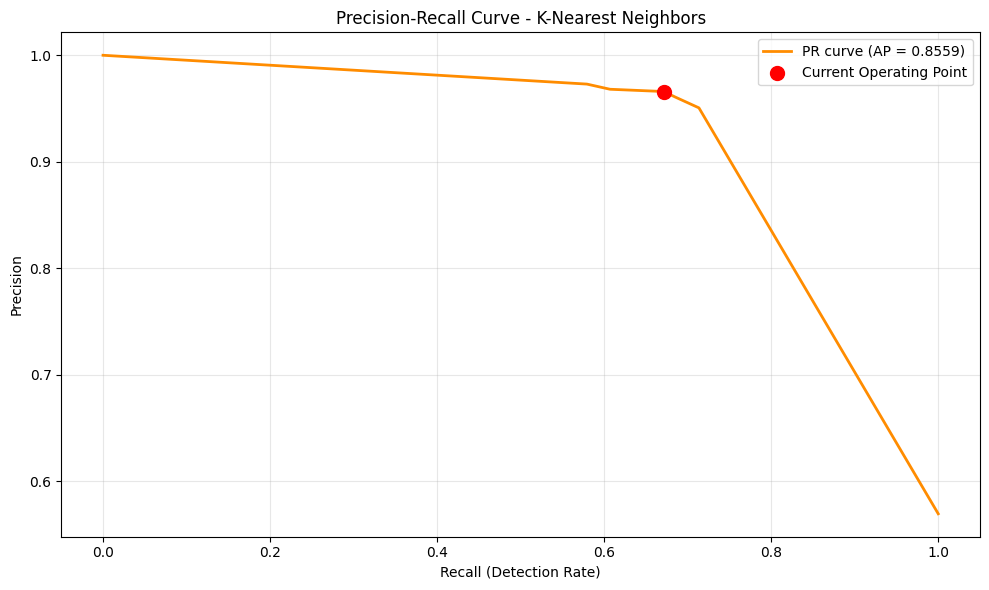

Average Precision (AP): 0.8559

Current (threshold=0.5):
  Precision: 0.9659
  Recall: 0.6715
  F1-Score: 0.7922

Best F1 threshold (threshold=0.200):
  Precision: 0.9506
  Recall: 0.7135
  F1-Score: 0.8151


In [2]:
print("PRECISION-RECALL ANALYSIS")
print("=" * 60)

# Get prediction probabilities
if hasattr(best_model, 'predict_proba'):
    y_scores = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    avg_precision = average_precision_score(y_test, y_scores)
    
    # Plot precision-recall curve
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, 
             label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall (Detection Rate)')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    
    # Mark your current operating point
    y_pred = best_model.predict(X_test)
    current_precision = precision_score(y_test, y_pred)
    current_recall = recall_score(y_test, y_pred)
    plt.scatter(current_recall, current_precision, color='red', s=100, 
                label='Current Operating Point', zorder=5)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('exports/plots/precision_recall_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find threshold that balances precision and recall
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])  # exclude last element
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Average Precision (AP): {avg_precision:.4f}")
    print(f"\nCurrent (threshold=0.5):")
    print(f"  Precision: {current_precision:.4f}")
    print(f"  Recall: {current_recall:.4f}")
    print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")
    
    print(f"\nBest F1 threshold (threshold={best_threshold:.3f}):")
    print(f"  Precision: {precision[best_idx]:.4f}")
    print(f"  Recall: {recall[best_idx]:.4f}")
    print(f"  F1-Score: {best_f1:.4f}")
else:
    print("Model does not support probability predictions.")

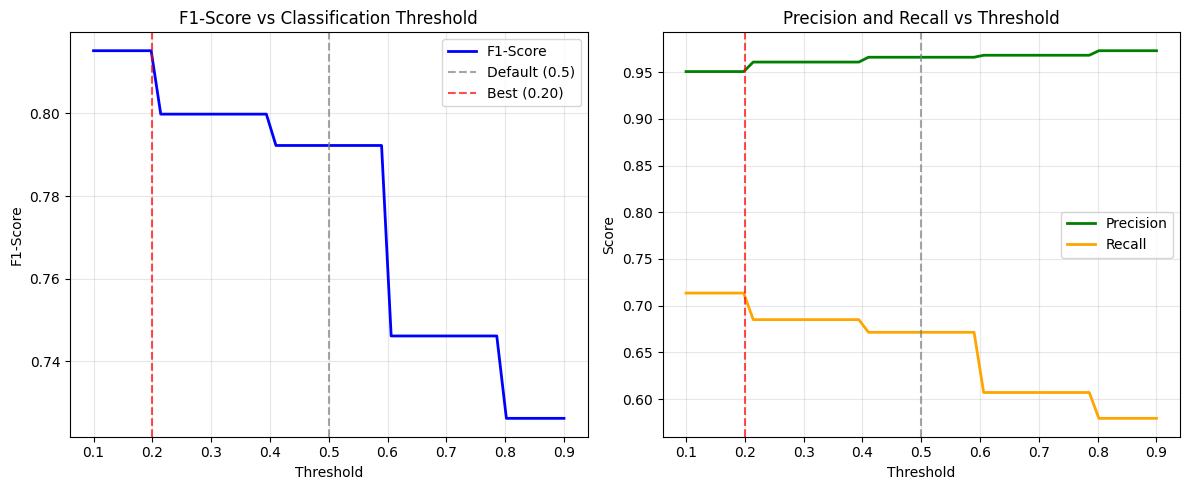

In [3]:
# Visualize how F1-score changes with threshold
if hasattr(best_model, 'predict_proba'):
    # Calculate metrics at different thresholds
    thresholds_range = np.linspace(0.1, 0.9, 50)
    f1_scores_thresh = []
    precisions_thresh = []
    recalls_thresh = []
    
    for thresh in thresholds_range:
        y_pred_thresh = (y_scores >= thresh).astype(int)
        f1_scores_thresh.append(f1_score(y_test, y_pred_thresh))
        precisions_thresh.append(precision_score(y_test, y_pred_thresh))
        recalls_thresh.append(recall_score(y_test, y_pred_thresh))
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(thresholds_range, f1_scores_thresh, 'b-', linewidth=2, label='F1-Score')
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
    plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7, label=f'Best ({best_threshold:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.title('F1-Score vs Classification Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(thresholds_range, precisions_thresh, 'g-', linewidth=2, label='Precision')
    plt.plot(thresholds_range, recalls_thresh, 'orange', linewidth=2, label='Recall')
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision and Recall vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('exports/plots/threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

LEARNING CURVE ANALYSIS
This shows how model performance improves with more training data


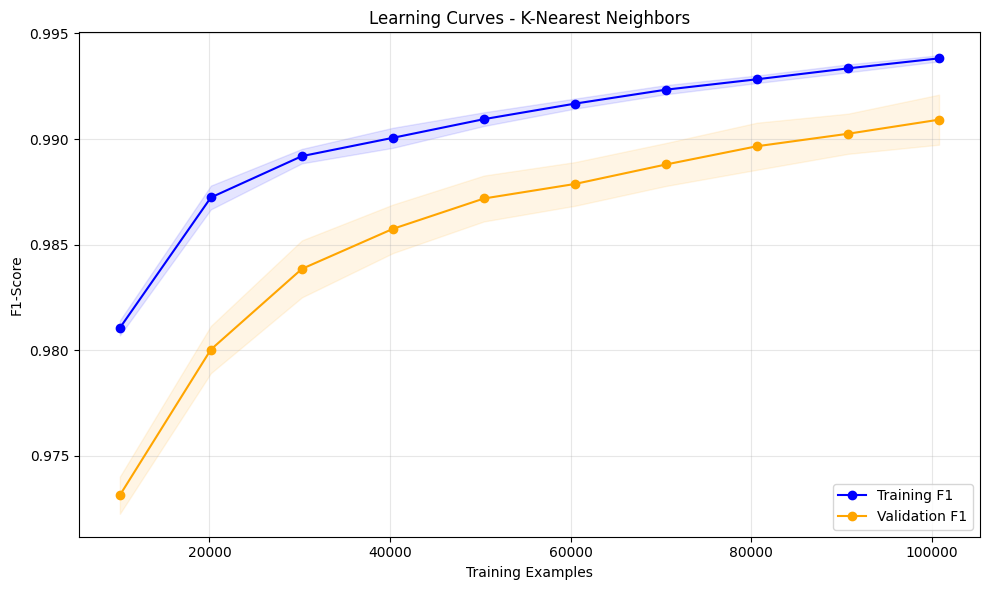


Final training F1: 0.9938
Final validation F1: 0.9909
Gap: 0.0029
 Small gap - Model generalizes well!


In [4]:
print("LEARNING CURVE ANALYSIS")
print("=" * 60)
print("This shows how model performance improves with more training data")

# Create learning curve
train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, 
    train_sizes=train_sizes, 
    cv=5, 
    scoring='f1',
    n_jobs=-1
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training F1')
plt.plot(train_sizes_abs, test_mean, 'o-', color='orange', label='Validation F1')
plt.xlabel('Training Examples')
plt.ylabel('F1-Score')
plt.title(f'Learning Curves - {model_name}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exports/plots/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpret the learning curve
final_train_f1 = train_mean[-1]
final_test_f1 = test_mean[-1]
gap = final_train_f1 - final_test_f1

print(f"\nFinal training F1: {final_train_f1:.4f}")
print(f"Final validation F1: {final_test_f1:.4f}")
print(f"Gap: {gap:.4f}")

if gap > 0.1:
    print(" High gap - Model is overfitting (learning noise, not patterns)")
elif gap > 0.05:
    print(" Moderate gap - Some overfitting, could use more data or regularization")
else:
    print(" Small gap - Model generalizes well!")

PERFORMANCE BY ATTACK TYPE
                 total  correct  detection_rate
actual_label                                   
ftp_write            3        0          0.0000
imap                 1        0          0.0000
loadmodule           2        0          0.0000
sqlattack            2        0          0.0000
sendmail            14        0          0.0000
snmpguess          331        0          0.0000
phf                  2        0          0.0000
perl                 2        0          0.0000
xlock                9        0          0.0000
xsnoop               4        0          0.0000
worm                 2        0          0.0000
guess_passwd      1231        7          0.0057
mailbomb           293        3          0.0102
snmpgetattack      178        3          0.0169
buffer_overflow     20        2          0.1000
multihop            18        2          0.1111
land                 7        1          0.1429
xterm               13        2          0.1538
named        

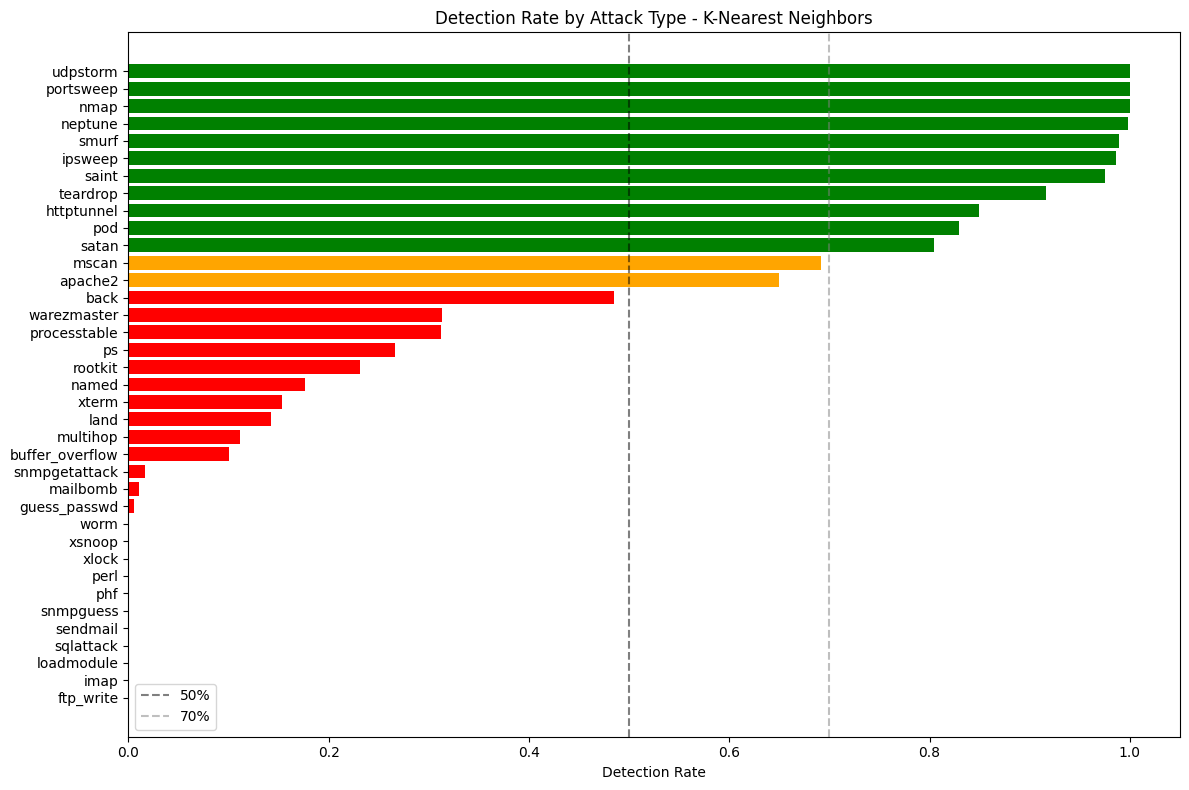


 Chart shows which attacks are easy (green) vs hard (red) to detect


In [5]:
# If you want to see performance on specific attack types
# This requires the original labels, not just binary

# Load original data with labels
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

original_test = pd.read_csv('data/raw/KDDTest+.txt', names=col_names)
original_test['binary'] = (original_test['label'] != 'normal').astype(int)

# Get predictions
y_pred = best_model.predict(X_test)

# Create a dataframe with actual labels and predictions
results_df = pd.DataFrame({
    'actual_label': original_test['label'],
    'actual_binary': original_test['binary'],
    'predicted_binary': y_pred
})

# Add correct/wrong column
results_df['correct'] = results_df['actual_binary'] == results_df['predicted_binary']

print("PERFORMANCE BY ATTACK TYPE")
print("=" * 60)

# Group by actual attack type
attack_performance = results_df[results_df['actual_binary'] == 1].groupby('actual_label').agg({
    'correct': ['count', 'sum', 'mean']
}).round(4)
attack_performance.columns = ['total', 'correct', 'detection_rate']
attack_performance = attack_performance.sort_values('detection_rate')

print(attack_performance)

# Visualize detection rates by attack type
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0.5 else 'orange' if x < 0.7 else 'green' for x in attack_performance['detection_rate']]
plt.barh(attack_performance.index, attack_performance['detection_rate'], color=colors)
plt.xlabel('Detection Rate')
plt.title(f'Detection Rate by Attack Type - {model_name}')
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='50%')
plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='70%')
plt.legend()
plt.tight_layout()
plt.savefig('exports/plots/attack_type_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart shows which attacks are easy (green) vs hard (red) to detect")

ERROR ANALYSIS
False Negatives (Missed Attacks): 4216
False Positives (False Alarms): 304

 ATTACKS MOST OFTEN MISSED (False Negatives):
  • guess_passwd: 1224 missed (out of 1231, 99.4% miss rate)
  • warezmaster: 648 missed (out of 944, 68.6% miss rate)
  • processtable: 471 missed (out of 685, 68.8% miss rate)
  • snmpguess: 331 missed (out of 331, 100.0% miss rate)
  • mscan: 307 missed (out of 996, 30.8% miss rate)
  • mailbomb: 290 missed (out of 293, 99.0% miss rate)
  • apache2: 258 missed (out of 737, 35.0% miss rate)
  • back: 185 missed (out of 359, 51.5% miss rate)
  • snmpgetattack: 175 missed (out of 178, 98.3% miss rate)
  • satan: 144 missed (out of 735, 19.6% miss rate)

📉 Confidence scores for missed attacks:
  Mean confidence: 0.0338
  Median confidence: 0.0000
  Min confidence: 0.0000
  Max confidence: 0.4000


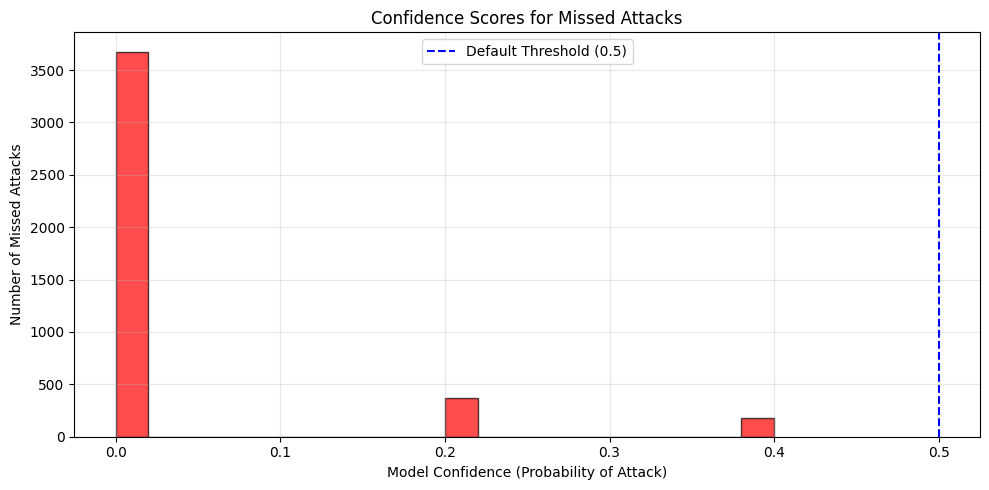

In [6]:
print("ERROR ANALYSIS")
print("=" * 60)

# Find false negatives (attacks misclassified as normal)
false_negatives = results_df[(results_df['actual_binary'] == 1) & (results_df['predicted_binary'] == 0)]
false_positives = results_df[(results_df['actual_binary'] == 0) & (results_df['predicted_binary'] == 1)]

print(f"False Negatives (Missed Attacks): {len(false_negatives)}")
print(f"False Positives (False Alarms): {len(false_positives)}")

# What types of attacks are most often missed?
print("\n ATTACKS MOST OFTEN MISSED (False Negatives):")
missed_attacks = false_negatives['actual_label'].value_counts().head(10)
for attack, count in missed_attacks.items():
    total = attack_performance.loc[attack, 'total'] if attack in attack_performance.index else 0
    miss_rate = count/total if total > 0 else 0
    print(f"  • {attack}: {count} missed (out of {total}, {miss_rate:.1%} miss rate)")

# If we have probability scores, analyze confidence of errors
if hasattr(best_model, 'predict_proba'):
    # Get probabilities for false negatives
    fn_indices = false_negatives.index
    fn_probs = y_scores[fn_indices]
    
    print("\n📉 Confidence scores for missed attacks:")
    print(f"  Mean confidence: {fn_probs.mean():.4f}")
    print(f"  Median confidence: {np.median(fn_probs):.4f}")
    print(f"  Min confidence: {fn_probs.min():.4f}")
    print(f"  Max confidence: {fn_probs.max():.4f}")
    
    # Plot histogram of missed attack confidences
    plt.figure(figsize=(10, 5))
    plt.hist(fn_probs, bins=20, color='red', alpha=0.7, edgecolor='black')
    plt.axvline(x=0.5, color='blue', linestyle='--', label='Default Threshold (0.5)')
    plt.xlabel('Model Confidence (Probability of Attack)')
    plt.ylabel('Number of Missed Attacks')
    plt.title('Confidence Scores for Missed Attacks')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('exports/plots/missed_attack_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()

CONFIDENCE CALIBRATION
This checks if when model says '90% confident', it's right 90% of the time


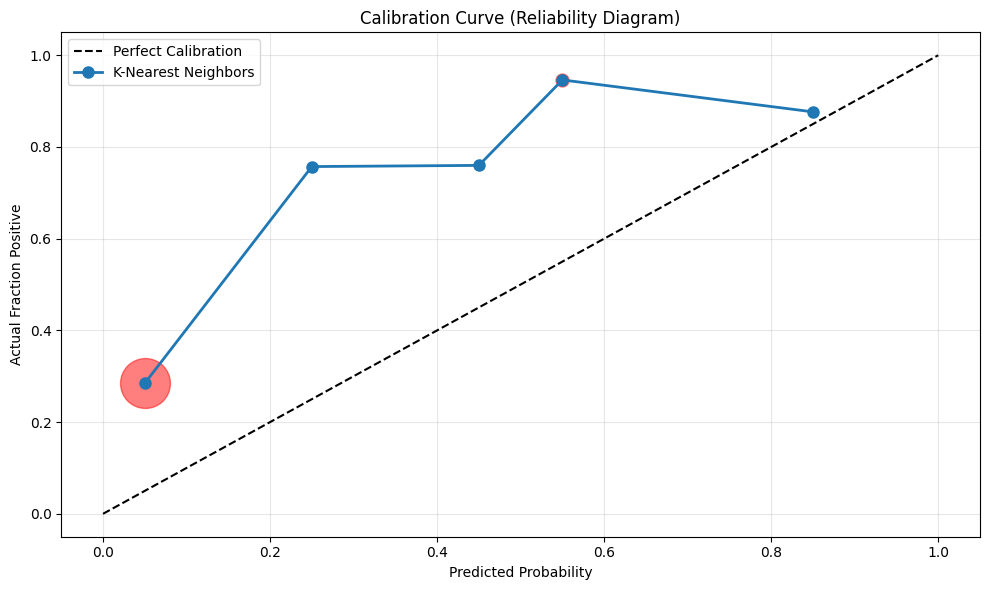

    bin  mid   actual  count
0.0-0.1 0.05 0.284774  12912
0.2-0.3 0.25 0.757261    482
0.4-0.5 0.45 0.759825    229
0.5-0.6 0.55 0.946224    874
0.8-0.9 0.85 0.876543    405


In [7]:
# Check if model confidence matches actual accuracy
if hasattr(best_model, 'predict_proba'):
    print("CONFIDENCE CALIBRATION")
    print("=" * 60)
    print("This checks if when model says '90% confident', it's right 90% of the time")
    
    # Bin predictions by confidence
    confidence_bins = np.linspace(0, 1, 11)
    bin_indices = np.digitize(y_scores, confidence_bins) - 1
    
    calibration_data = []
    for i in range(len(confidence_bins)-1):
        mask = (bin_indices == i)
        if np.sum(mask) > 0:
            bin_conf = confidence_bins[i] + 0.05  # mid point
            actual_pos = np.mean(y_test[mask])
            count = np.sum(mask)
            calibration_data.append({
                'bin': f'{confidence_bins[i]:.1f}-{confidence_bins[i+1]:.1f}',
                'mid': bin_conf,
                'actual': actual_pos,
                'count': count
            })
    
    cal_df = pd.DataFrame(calibration_data)
    
    # Plot calibration curve
    plt.figure(figsize=(10, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    plt.plot(cal_df['mid'], cal_df['actual'], 'o-', linewidth=2, markersize=8, label=model_name)
    
    # Add size of each bin as point size
    sizes = cal_df['count'] / cal_df['count'].max() * 500
    
    for i, row in cal_df.iterrows():
        plt.scatter(row['mid'], row['actual'], s=row['count']/10, alpha=0.5, color='red')
    
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Fraction Positive')
    plt.title('Calibration Curve (Reliability Diagram)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('exports/plots/calibration_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(cal_df.to_string(index=False))

In [8]:
print("=" * 60)
print(" ADVANCED EVALUATION SUMMARY")
print("=" * 60)

# Basic metrics
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model: {model_name}")
print(f"\n📈 CORE METRICS:")
print(f"  • Accuracy:  {accuracy:.4f}")
print(f"  • Precision: {precision:.4f}")
print(f"  • Recall:    {recall:.4f}")
print(f"  • F1-Score:  {f1:.4f}")

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\n CONFUSION MATRIX:")
print(f"  • True Negatives:  {tn:6d} (Correctly identified normal)")
print(f"  • False Positives: {fp:6d} (False alarms)")
print(f"  • False Negatives: {fn:6d} (Missed attacks)")
print(f"  • True Positives:  {tp:6d} (Correctly detected attacks)")

print(f"\n IDS-SPECIFIC METRICS:")
print(f"  • Detection Rate (TPR):     {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.1f}% of attacks caught)")
print(f"  • False Alarm Rate (FPR):   {fp/(fp+tn):.4f} ({fp/(fp+tn)*100:.1f}% of normal flagged)")
print(f"  • Miss Rate (FNR):          {fn/(tp+fn):.4f} ({fn/(tp+fn)*100:.1f}% of attacks missed)")

if hasattr(best_model, 'predict_proba'):
    roc_auc = roc_auc_score(y_test, y_scores)
    print(f"  • ROC-AUC:                  {roc_auc:.4f}")

print("\n Advanced evaluation complete!")
print(" Visualizations saved to exports/plots/")

 ADVANCED EVALUATION SUMMARY
Model: K-Nearest Neighbors

📈 CORE METRICS:
  • Accuracy:  0.7995
  • Precision: 0.9659
  • Recall:    0.6715
  • F1-Score:  0.7922

 CONFUSION MATRIX:
  • True Negatives:    9407 (Correctly identified normal)
  • False Positives:    304 (False alarms)
  • False Negatives:   4216 (Missed attacks)
  • True Positives:    8617 (Correctly detected attacks)

 IDS-SPECIFIC METRICS:
  • Detection Rate (TPR):     0.6715 (67.1% of attacks caught)
  • False Alarm Rate (FPR):   0.0313 (3.1% of normal flagged)
  • Miss Rate (FNR):          0.3285 (32.9% of attacks missed)
  • ROC-AUC:                  0.8393

 Advanced evaluation complete!
 Visualizations saved to exports/plots/


In [9]:
# Save evaluation results to CSV
evaluation_summary = pd.DataFrame([{
    'Model': model_name,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1,
    'True_Negatives': tn,
    'False_Positives': fp,
    'False_Negatives': fn,
    'True_Positives': tp,
    'Detection_Rate': tp/(tp+fn),
    'False_Alarm_Rate': fp/(fp+tn),
    'Miss_Rate': fn/(tp+fn)
}])

evaluation_summary.to_csv('results/advanced_evaluation.csv', index=False)
print(" Evaluation report saved to: results/advanced_evaluation.csv")

 Evaluation report saved to: results/advanced_evaluation.csv
